# Response functions
This notebook provides an overview of the response functions that are available in Pastas. Response functions describe the response of the dependent variable (an `oseries` like groundwater heads) to an independent variable (a `stress` like precipitation or groundwater pumping) and form a fundamental part in the approach implemented in Pastas. Depending on the problem under investigation, a response function may be required with a certain shape or with more degrees of freedom (parameters). Response functions are generally used in combination with a stress model, but in this notebook the response functions are discussed independently to provide an overview of the different response functions and what they represent.

In [11]:
from inspect import getsource

import matplotlib.pyplot as plt
import pandas as pd

import pastas as ps

ps.show_versions()

Pastas     : 2.0.0
Python     : 3.13.5
Numpy      : 2.4.4
Pandas     : 3.0.2
Scipy      : 1.17.1
Matplotlib : 3.10.9
Numba      : 0.65.1



## Response functions available in Pastas
The following response functions are available in Pastas:

In [12]:
ps.rfunc.__all__

['Gamma',
 'Exponential',
 'Hantush',
 'Polder',
 'FourParam',
 'DoubleExponential',
 'One',
 'Edelman',
 'HantushWellModel',
 'Kraijenhoff',
 'Spline']

Below we discuss the some of the most used response functions and what they represent:

### Exponential response function
The exponential response function is the simplest response function with only two parameters: a scaling parameter $A$ and a shape parameter $a$. The response function may be used for stresses that start to have an immediate effect on the head, for example precipitation in a shallow aquifer. The step response function plateaus at $A$ (the gain is $A$). 
The equation for the impulse response is:

In [15]:
print(getsource(ps.Exponential.impulse))

    @staticmethod
    def impulse(t: ArrayLike, p: ArrayLike) -> ArrayLike:
        A, a = p
        return A / a * np.exp(-t / a)



### Gamma response function
The Gamma response function is slightly more complicated than the exponential response function and has one additional shape parameter $n$. When $n>1$, there is a delay in the response. When $n=1$, the Gamma response is the same as the Exponential response. When $n<1$ there is an immediate response. The response function is the most used response function in Pastas, as its shape is versatile and able to mimic many responses found in the field (it is also used in many other parts of hydrology to simulate a hydrological response).  The step response plateaus at $A$ (the gain is $A$). The equation for the impulse response is:

In [16]:
print(getsource(ps.Gamma.impulse))

    @staticmethod
    def impulse(t: ArrayLike, p: ArrayLike) -> ArrayLike:
        A, n, a = p
        return A * t ** (n - 1) * np.exp(-t / a) / (a**n * gamma(n))



### Hantush response function
The Hantush response function is intended for the simulation of the response of pumping wells. It is based on the classic Hantush function for pumping in a semi-confined aquifer. The response function has one scale parameter $A$ and two shape parameters $a$ and $b$.  
The step response plateaus at $A$ (the gain is $A$). The equation for the impulse response is:

In [18]:
print(getsource(ps.Hantush.impulse))

    @staticmethod
    def impulse(t: ArrayLike, p: ArrayLike) -> ArrayLike:
        A, a, b = p
        return A / (2 * t * k0(2 * np.sqrt(b))) * np.exp(-t / a - a * b / t)



### Double exponential function
The Double exponential response function is intended for the simulation in a multi-aquifer system, with an initially a quick response and after that a slower response. It consists of two exponential functions and contains four parameters: the scale parameter $A$, two shape parameters $a_1$ and $a_2$, and a parameter $\alpha$ that distributes the response between the two exponential functions. The step response plateaus at $A$ (the gain is $A$). The Double exponential function is not applied very often in practice. The equation for the impulse response is:

In [20]:
print(getsource(ps.DoubleExponential.impulse))

    @staticmethod
    def impulse(t: ArrayLike, p: ArrayLike) -> ArrayLike:
        A, alpha, a_1, a_2 = p
        return A * (
            (1 - alpha) / a_1 * np.exp(-t / a_1) + alpha / a_2 * np.exp(-t / a_2)
        )



### Polder function
The Polder response function is intended for the simulation of the response to variations of surface water levels. It is based on the response of a semi-confined aquifer to a variation in the surface water boundary. The response function has one scale parameter $A$ and two shape parameters $a$ and $b$. The step response plateaus at $A\exp(-2\sqrt{b})$ (the gain is $A\exp(-2\sqrt{b})$. The equation for the impulse response is:

In [22]:
print(getsource(ps.Polder.impulse))

    @staticmethod
    def impulse(t: ArrayLike, p: ArrayLike) -> ArrayLike:
        A, a, b = p
        return A * np.sqrt(a * b / pi) * t ** (-1.5) * np.exp(-t / a - a * b / t)



### Four parameter function
The four parameter function is a function with four parameters that includes the Exponential, Gamma, Hantush and Polder functions as a special case. It is the most general function, but it is relatively slow to compute. This function needs further documentation.

In [24]:
print(getsource(ps.FourParam.impulse))

    @staticmethod
    def impulse(t: ArrayLike, p: ArrayLike) -> ArrayLike:
        _, n, a, b = p
        return (t ** (n - 1)) * np.exp(-t / a - a * b / t)



### Examples of response functions
A few example response functions are plotted below

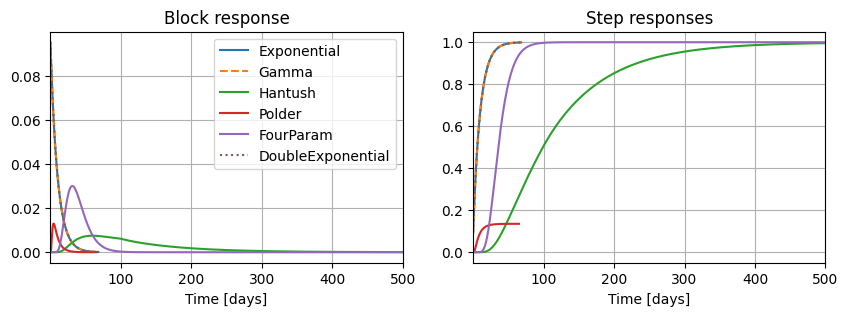

In [25]:
# Default Settings
cutoff = 0.999
gain_scale_factor = 1
up = True

responses = {}
exp = ps.Exponential()
responses["Exponential"] = exp

gamma = ps.Gamma()
responses["Gamma"] = gamma

hantush = ps.Hantush()
responses["Hantush"] = hantush

polder = ps.Polder()
responses["Polder"] = polder

fourp = ps.FourParam()
responses["FourParam"] = fourp

DoubleExp = ps.DoubleExponential()
responses["DoubleExponential"] = DoubleExp

parameters = pd.DataFrame()

fig, [ax1, ax2] = plt.subplots(1, 2, sharex=True, figsize=(10, 3))

for name, response in responses.items():
    p = response.get_init_parameters(name)
    parameters = pd.concat([parameters, p], axis=0)
    ls = "-"
    if name == "Gamma":
        ls = "--"
    elif name == "DoubleExponential":
        ls = ":"
    ax1.plot(response.block(p.initial.values), label=name, ls=ls)
    ax2.plot(response.step(p.initial.values), label=name, ls=ls)

ax1.set_title("Block response")
ax1.grid()
ax2.set_title("Step responses")
ax2.grid()
ax1.set_xlabel("Time [days]")
ax2.set_xlabel("Time [days]")
ax1.legend()
plt.xlim(1e-1, 500)
plt.show()